In [ ]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import scipy.stats as st

# Display all columns when using df.head()
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

: 

## Extract Data

In [ ]:
df = pd.read_csv("../data/Data.csv")
print("Success Import")

Success Import


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3585 entries, 0 to 3584
Data columns (total 28 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Gps Provider                        3585 non-null   object 
 1   Booking ID                          3585 non-null   object 
 2   Shipment Type                       3585 non-null   object 
 3   Booking Date                        3585 non-null   object 
 4   Vehicle Registration                3585 non-null   object 
 5   Origin Location                     3585 non-null   object 
 6   Destination Location                3585 non-null   object 
 7   Origin Location Latitude            3585 non-null   float64
 8   Origin Location Longitude           3585 non-null   float64
 9   Destination Location Latitude       3585 non-null   float64
 10  Destination Location Longitude      3585 non-null   float64
 11  Data Ping time                      3584 no

In [4]:
print("\nFirst 5 rows")
df.head()


First 5 rows


,Gps Provider,Booking ID,Shipment Type,Booking Date,Vehicle Registration,Origin Location,Destination Location,Origin Location Latitude,Origin Location Longitude,Destination Location Latitude,Destination Location Longitude,Data Ping time,Planned ETA,Current Location,Actual ETA,Current Location Latitude,Curren Location Longitude,Ontime,Trip Start Date,Trip End Date,Transportation Distance (KM),Vehicle Type,Minimum Kms To Be Covered In A Day,Driver Name,Driver Mobile No,Customer Name,Supplier Name,Material Shipped
0,Consent Track,AEIBK2027469,Regular,8/26/2020,MH14GD9464,"Shive, Pune, Maharashtra","Pondur, Kanchipuram, Tamil Nadu",18.750621,73.877190,12.930429,79.931163,15:10.0,03:46.0,"Singaperumal Koil - Sriperumbudur Rd, Oragadam...",8/28/20 12:48,12.837127,79.951866,Yes,8/26/20 16:16,8/28/20 12:15,1290.0,32 FT Multi-Axle 14MT - HCV,NaN,VIRAT NILAPALLE,9.960008e+09,Daimler India Commercial Vehicles Pvt Lt,Oms Logistics Pvt Ltd,Regulator - 12v
1,Vamosys,VCV00014153/082021,Regular,8/27/2020,TN30BC9320,"Daimler India Commercial Vehicles,Kanchipuram,...","Daimler India Commercial Vehicles,Kanchipuram,...",12.839000,79.954000,12.839000,79.954000,35:40.0,21:48.6,"Gokulapuram Main Rd, Maraimalai Nagar, Tamil N...",8/28/20 12:13,12.768090,80.026660,Yes,8/27/20 15:21,8/27/20 15:21,29.0,NaN,NaN,SENTHIL KUMAR,NaN,Daimler India Commercial Vehicles Pvt Lt,Vj Logistics,Valve Spring
2,Vamosys,VCV00014063/082021,Regular,8/27/2020,TN30BB1036,"Daimler India Commercial Vehicles,Kanchipuram,...","Daimler India Commercial Vehicles,Kanchipuram,...",12.839000,79.954000,12.839000,79.954000,25:38.0,22:17.8,"Singaperumal Koil - Sriperumbudur Rd, Oragadam...",8/28/20 11:33,12.835262,79.952533,Yes,8/27/20 14:21,8/27/20 14:22,21.0,NaN,NaN,ANBU,NaN,Daimler India Commercial Vehicles Pvt Lt,Vj Logistics,Valve Spring
3,Vamosys,VCV00014741/082021,Regular,8/28/2020,TN88D4134,"Daimler India Commercial Vehicles,Kanchipuram,...","Daimler India Commercial Vehicles,Kanchipuram,...",12.839000,79.954000,12.839000,79.954000,25:37.0,32:20.5,"Unnamed Road, Oragadam Industrial Corridor, Or...",8/28/20 11:31,12.839172,79.951355,Yes,8/28/20 0:31,8/28/20 0:32,20.0,NaN,NaN,SUDHAKAR,NaN,Daimler India Commercial Vehicles Pvt Lt,Namakkal Sri Anjinaya Transport,Lu Hood Lock / Rh
4,Consent Track,AEIBK2027446,Regular,8/26/2020,GJ01DZ8943,"Khorajnanoda, Ahmedabad, Gujarat","Singaperumalkoil, Kanchipuram, Tamil Nadu",22.961777,72.094219,12.786517,79.975221,35:08.0,55:08.0,"Rajmata Jijau Marg, Suhash Colony, Beed, Mahar...",8/29/20 7:09,18.996400,75.740200,Yes,8/26/20 15:35,8/28/20 11:21,1900.0,32 FT Single-Axle 7MT - HCV,NaN,MAN SINGH,6.396821e+09,Ford India Private Limited,Sterling Translogistics Private Limited,Lu Latch / Pin


In [5]:
print("\nLast 5 rows")
df.tail()


Last 5 rows


,Gps Provider,Booking ID,Shipment Type,Booking Date,Vehicle Registration,Origin Location,Destination Location,Origin Location Latitude,Origin Location Longitude,Destination Location Latitude,Destination Location Longitude,Data Ping time,Planned ETA,Current Location,Actual ETA,Current Location Latitude,Curren Location Longitude,Ontime,Trip Start Date,Trip End Date,Transportation Distance (KM),Vehicle Type,Minimum Kms To Be Covered In A Day,Driver Name,Driver Mobile No,Customer Name,Supplier Name,Material Shipped
3580,Consent Track,AEIBK1909187,Regular,12/20/2019,HR38S1605,"Okhla industrial estate, south delhi, delhi","Palam Airport, South West Delhi, Delhi",28.542809,77.280521,28.553908,77.090981,45:15.0,18:06.0,"Unnamed Road, Tekhand, Okhla Phase I, Okhla In...",12/22/19 1:51,28.523281,77.287640,No,12/20/19 14:54,1/16/20 15:57,25.0,40 FT 3XL Trailer 35MT,250.0,NaN,NaN,Larsen & Toubro Limited,S.B.Transport Company,Yoke & Pole Assembly
3581,Consent Track,AEIBK1907026,Regular,11/29/2019,NL01G0589,"Kuldanga, howrah, west bengal","Kuldanga, Howrah, West Bengal",16.560192,80.792293,22.593221,88.472233,05:13.0,06:49.0,"45, Grand Trunk Rd, Naora, Shibpur, Howrah, We...",12/18/19 15:52,25.136247,82.566526,No,11/29/19 21:14,2/5/20 16:57,30.0,40 FT Flat Bed Double-Axle 21MT - Trailer,250.0,NaN,NaN,Larsen & Toubro Limited,Sunita Carriers Private Limited,Rectifier Assembly
3582,Consent Track,AEIBK1906955,Regular,11/30/2019,GJ15UU7437,"Changodar, ahmedabad, gujarat","Zanu, Ahmedabad, Gujarat",16.560192,80.792293,23.042185,72.697893,50:15.0,34:27.0,"Unnamed Road, Gujarat 391243, India",12/11/19 3:36,22.190830,73.078550,No,11/30/19 15:10,1/2/20 14:24,25.0,40 FT 3XL Trailer 35MT,250.0,MAHENDRA SINGH,8.949298e+09,Larsen & Toubro Limited,Balaji Freight Carrier,Grs Starter
3583,Null,WDSBKTP49392,Regular,6/10/2019,WB59B9152,"Sonai, kolkata, west bengal","Kalyani, Nadia, West Bengal",23.525268,87.264424,22.952176,88.457141,NaN,1899-12-30 08:58:00.000,Null,1899-12-30 08:13:00.000,NaN,NaN,Yes,1899-12-30 00:00:00.000,1899-12-30 08:13:00.000,51.0,40 FT Flat Bed Multi-Axle 27MT - Trailer,NaN,NaN,NaN,Larsen & Toubro Limited,Sunita Carriers Private Limited,Fxuwb-Lid Cover
3584,Jtech,WDSBKTP44502,Regular,4/15/2019,KA21A5090,"Mugabala, bangalore rural, karnataka","Peenya Small Industries, Bangalore, Karnataka",16.560192,80.792293,13.196313,77.708157,20:12.0,1899-12-30 04:06:00.000,"Shed No 60, Medahalli Kadugodi Road, Virgonaga...",1899-12-30 03:21:00.000,13.025077,77.723114,No,1899-12-30 00:00:00.000,1899-12-30 03:21:00.000,41.0,40 FT 3XL Trailer 35MT,NaN,NaN,NaN,Larsen & Toubro Limited,A S Transports,Insrt-Vlv St Intk


## Transform

### Correct column name

In [6]:
# Correct Misspelling Column
df.rename(columns={'Curren Location Longitude': 'Current Location Longitude'}, inplace=True)
df.columns = df.columns.str.strip()

In [7]:
# Swap column names to correct the mislabeling issue
print("="*70)
print("CORRECTING COLUMN NAME LABELS")
print("="*70)

print("\nBefore correction:")
print(f"  - Trip End Date column contains: ACTUAL arrival times")
print(f"  - Actual ETA column contains: ESTIMATED/PLANNED arrival times")

# Rename columns to match their actual content based on data dictionary
df.rename(columns={
    'Trip End Date': 'Estimate Time Arrival',
    'Actual ETA': 'Actual Time Arrival'
}, inplace=True)

print("\nAfter correction:")
print(f"  - Estimate Time Arrival: Contains actual arrival times (was 'Trip End Date')")
print(f"  - Actual Time Arrival: Contains planned/estimated arrival times (was 'Actual ETA')")

CORRECTING COLUMN NAME LABELS

Before correction:
  - Trip End Date column contains: ACTUAL arrival times
  - Actual ETA column contains: ESTIMATED/PLANNED arrival times

After correction:
  - Estimate Time Arrival: Contains actual arrival times (was 'Trip End Date')
  - Actual Time Arrival: Contains planned/estimated arrival times (was 'Actual ETA')


### Null and duplicate value cleaning

In [8]:
print("Null values:")
null_number = df.isnull().sum()
null_percent = round(df.isnull().sum() / len(df) * 100, 2)

null_df = pd.DataFrame({"Null Count": null_number, "Null Percentage": null_percent})

null_df = null_df[null_df["Null Count"] > 0].sort_values(by="Null Count", ascending=False)

print(null_df)

print("-"*20)
print("Duplicate rows:")
print(df.duplicated().sum())

Null values:
                                    Null Count  Null Percentage
Minimum Kms To Be Covered In A Day        2645            73.78
Driver Mobile No                          1024            28.56
Vehicle Type                               764            21.31
Driver Name                                317             8.84
Transportation Distance (KM)               148             4.13
Actual Time Arrival                         25             0.70
Data Ping time                               1             0.03
Current Location Longitude                   1             0.03
Current Location Latitude                    1             0.03
--------------------
Duplicate rows:
0


In [9]:
# Drop columns with null values which have more than 50% null values
cols_to_drop = ['Minimum Kms To Be Covered In A Day', 'Driver Mobile No']
for col in cols_to_drop:
    if col in df.columns:
        print(f"Dropping column: {col}")
        df.drop(columns=[col], inplace=True)

Dropping column: Minimum Kms To Be Covered In A Day
Dropping column: Driver Mobile No


In [10]:
# Fill null values in 'Vehicle Type' and 'Driver Name' with 'Not Specified'
cols_fill_unknown = ['Vehicle Type', 'Driver Name']
for col in cols_fill_unknown:
    df[col] = df[col].fillna('Not Specified')

In [11]:
df['Transportation Distance (KM)'] = df.groupby(
    ['Origin Location', 'Destination Location']
)['Transportation Distance (KM)'].transform(
    lambda x: x.fillna(x.median())
)

df['Transportation Distance (KM)'] = df['Transportation Distance (KM)'].fillna(
    df['Transportation Distance (KM)'].median()
)

c:\Users\AD\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\AD\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\AD\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\AD\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


c:\Users\AD\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\AD\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\AD\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\AD\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\AD\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepd

In [12]:
# Remove rows with null values in 'Actual ETA', 'Current Location Latitude', and 'Current Location Longitude'
print("\nBefore remove null:")
print(len(df))
df.dropna(subset=['Actual Time Arrival', 'Current Location Latitude', 'Current Location Longitude', 'Data Ping time'], inplace=True)
print("\nAfter remove null:")
print(len(df))


Before remove null:
3585

After remove null:
3559


In [13]:
# Final check after null and duplicate cleaning
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3559 entries, 0 to 3584
Data columns (total 26 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gps Provider                    3559 non-null   object 
 1   Booking ID                      3559 non-null   object 
 2   Shipment Type                   3559 non-null   object 
 3   Booking Date                    3559 non-null   object 
 4   Vehicle Registration            3559 non-null   object 
 5   Origin Location                 3559 non-null   object 
 6   Destination Location            3559 non-null   object 
 7   Origin Location Latitude        3559 non-null   float64
 8   Origin Location Longitude       3559 non-null   float64
 9   Destination Location Latitude   3559 non-null   float64
 10  Destination Location Longitude  3559 non-null   float64
 11  Data Ping time                  3559 non-null   object 
 12  Planned ETA                     3559 no

In [14]:
print("First 5 rows")
df.head()

First 5 rows


,Gps Provider,Booking ID,Shipment Type,Booking Date,Vehicle Registration,Origin Location,Destination Location,Origin Location Latitude,Origin Location Longitude,Destination Location Latitude,Destination Location Longitude,Data Ping time,Planned ETA,Current Location,Actual Time Arrival,Current Location Latitude,Current Location Longitude,Ontime,Trip Start Date,Estimate Time Arrival,Transportation Distance (KM),Vehicle Type,Driver Name,Customer Name,Supplier Name,Material Shipped
0,Consent Track,AEIBK2027469,Regular,8/26/2020,MH14GD9464,"Shive, Pune, Maharashtra","Pondur, Kanchipuram, Tamil Nadu",18.750621,73.877190,12.930429,79.931163,15:10.0,03:46.0,"Singaperumal Koil - Sriperumbudur Rd, Oragadam...",8/28/20 12:48,12.837127,79.951866,Yes,8/26/20 16:16,8/28/20 12:15,1290.0,32 FT Multi-Axle 14MT - HCV,VIRAT NILAPALLE,Daimler India Commercial Vehicles Pvt Lt,Oms Logistics Pvt Ltd,Regulator - 12v
1,Vamosys,VCV00014153/082021,Regular,8/27/2020,TN30BC9320,"Daimler India Commercial Vehicles,Kanchipuram,...","Daimler India Commercial Vehicles,Kanchipuram,...",12.839000,79.954000,12.839000,79.954000,35:40.0,21:48.6,"Gokulapuram Main Rd, Maraimalai Nagar, Tamil N...",8/28/20 12:13,12.768090,80.026660,Yes,8/27/20 15:21,8/27/20 15:21,29.0,Not Specified,SENTHIL KUMAR,Daimler India Commercial Vehicles Pvt Lt,Vj Logistics,Valve Spring
2,Vamosys,VCV00014063/082021,Regular,8/27/2020,TN30BB1036,"Daimler India Commercial Vehicles,Kanchipuram,...","Daimler India Commercial Vehicles,Kanchipuram,...",12.839000,79.954000,12.839000,79.954000,25:38.0,22:17.8,"Singaperumal Koil - Sriperumbudur Rd, Oragadam...",8/28/20 11:33,12.835262,79.952533,Yes,8/27/20 14:21,8/27/20 14:22,21.0,Not Specified,ANBU,Daimler India Commercial Vehicles Pvt Lt,Vj Logistics,Valve Spring
3,Vamosys,VCV00014741/082021,Regular,8/28/2020,TN88D4134,"Daimler India Commercial Vehicles,Kanchipuram,...","Daimler India Commercial Vehicles,Kanchipuram,...",12.839000,79.954000,12.839000,79.954000,25:37.0,32:20.5,"Unnamed Road, Oragadam Industrial Corridor, Or...",8/28/20 11:31,12.839172,79.951355,Yes,8/28/20 0:31,8/28/20 0:32,20.0,Not Specified,SUDHAKAR,Daimler India Commercial Vehicles Pvt Lt,Namakkal Sri Anjinaya Transport,Lu Hood Lock / Rh
4,Consent Track,AEIBK2027446,Regular,8/26/2020,GJ01DZ8943,"Khorajnanoda, Ahmedabad, Gujarat","Singaperumalkoil, Kanchipuram, Tamil Nadu",22.961777,72.094219,12.786517,79.975221,35:08.0,55:08.0,"Rajmata Jijau Marg, Suhash Colony, Beed, Mahar...",8/29/20 7:09,18.996400,75.740200,Yes,8/26/20 15:35,8/28/20 11:21,1900.0,32 FT Single-Axle 7MT - HCV,MAN SINGH,Ford India Private Limited,Sterling Translogistics Private Limited,Lu Latch / Pin


In [15]:
print("\nLast 5 rows")
df.tail()


Last 5 rows


,Gps Provider,Booking ID,Shipment Type,Booking Date,Vehicle Registration,Origin Location,Destination Location,Origin Location Latitude,Origin Location Longitude,Destination Location Latitude,Destination Location Longitude,Data Ping time,Planned ETA,Current Location,Actual Time Arrival,Current Location Latitude,Current Location Longitude,Ontime,Trip Start Date,Estimate Time Arrival,Transportation Distance (KM),Vehicle Type,Driver Name,Customer Name,Supplier Name,Material Shipped
3579,Consent Track,AEIBK1909185,Regular,12/20/2019,HR38R0190,"Okhla industrial estate, south delhi, delhi","Palam Airport, South West Delhi, Delhi",28.542809,77.280521,28.553908,77.090981,00:19.0,18:04.0,"B-4, 5,6,7,8, Pocket B, Okhla Phase I, Okhla I...",12/22/19 1:49,28.526886,77.284454,No,12/20/19 14:54,1/17/20 17:56,25.0,40 FT 3XL Trailer 35MT,Not Specified,Larsen & Toubro Limited,S.B.Transport Company,Rectifer
3580,Consent Track,AEIBK1909187,Regular,12/20/2019,HR38S1605,"Okhla industrial estate, south delhi, delhi","Palam Airport, South West Delhi, Delhi",28.542809,77.280521,28.553908,77.090981,45:15.0,18:06.0,"Unnamed Road, Tekhand, Okhla Phase I, Okhla In...",12/22/19 1:51,28.523281,77.287640,No,12/20/19 14:54,1/16/20 15:57,25.0,40 FT 3XL Trailer 35MT,Not Specified,Larsen & Toubro Limited,S.B.Transport Company,Yoke & Pole Assembly
3581,Consent Track,AEIBK1907026,Regular,11/29/2019,NL01G0589,"Kuldanga, howrah, west bengal","Kuldanga, Howrah, West Bengal",16.560192,80.792293,22.593221,88.472233,05:13.0,06:49.0,"45, Grand Trunk Rd, Naora, Shibpur, Howrah, We...",12/18/19 15:52,25.136247,82.566526,No,11/29/19 21:14,2/5/20 16:57,30.0,40 FT Flat Bed Double-Axle 21MT - Trailer,Not Specified,Larsen & Toubro Limited,Sunita Carriers Private Limited,Rectifier Assembly
3582,Consent Track,AEIBK1906955,Regular,11/30/2019,GJ15UU7437,"Changodar, ahmedabad, gujarat","Zanu, Ahmedabad, Gujarat",16.560192,80.792293,23.042185,72.697893,50:15.0,34:27.0,"Unnamed Road, Gujarat 391243, India",12/11/19 3:36,22.190830,73.078550,No,11/30/19 15:10,1/2/20 14:24,25.0,40 FT 3XL Trailer 35MT,MAHENDRA SINGH,Larsen & Toubro Limited,Balaji Freight Carrier,Grs Starter
3584,Jtech,WDSBKTP44502,Regular,4/15/2019,KA21A5090,"Mugabala, bangalore rural, karnataka","Peenya Small Industries, Bangalore, Karnataka",16.560192,80.792293,13.196313,77.708157,20:12.0,1899-12-30 04:06:00.000,"Shed No 60, Medahalli Kadugodi Road, Virgonaga...",1899-12-30 03:21:00.000,13.025077,77.723114,No,1899-12-30 00:00:00.000,1899-12-30 03:21:00.000,41.0,40 FT 3XL Trailer 35MT,Not Specified,Larsen & Toubro Limited,A S Transports,Insrt-Vlv St Intk


### Correct data format

In [16]:
date_columns = ['Booking Date', 'Actual Time Arrival', 'Trip Start Date', 'Estimate Time Arrival']
for col in date_columns:
    df[col] = pd.to_datetime(df[col], errors='coerce')

df.info()

C:\Users\AD\AppData\Local\Temp\ipykernel_20660\2987641182.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors='coerce')


C:\Users\AD\AppData\Local\Temp\ipykernel_20660\2987641182.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors='coerce')
C:\Users\AD\AppData\Local\Temp\ipykernel_20660\2987641182.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors='coerce')


<class 'pandas.core.frame.DataFrame'>
Index: 3559 entries, 0 to 3584
Data columns (total 26 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   Gps Provider                    3559 non-null   object        
 1   Booking ID                      3559 non-null   object        
 2   Shipment Type                   3559 non-null   object        
 3   Booking Date                    3559 non-null   datetime64[ns]
 4   Vehicle Registration            3559 non-null   object        
 5   Origin Location                 3559 non-null   object        
 6   Destination Location            3559 non-null   object        
 7   Origin Location Latitude        3559 non-null   float64       
 8   Origin Location Longitude       3559 non-null   float64       
 9   Destination Location Latitude   3559 non-null   float64       
 10  Destination Location Longitude  3559 non-null   float64       
 11  Data Ping

In [17]:
def parse_duration(time_str):
    if pd.isna(time_str) or '-' in str(time_str):
        return pd.NaT
    try:
        parts = str(time_str).split(':')
        hh = int(parts[0])
        mm = float(parts[1])
        
        return pd.Timedelta(hours=hh, minutes=mm)
    except:
        return pd.NaT

col_to_correct = ['Planned ETA', 'Data Ping time']
for i in col_to_correct:
    try:
        df[i] = df[i].apply(parse_duration)
    except Exception as e:
        print(f"Error parsing duration for column {i}: {e}")

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3559 entries, 0 to 3584
Data columns (total 26 columns):
 #   Column                          Non-Null Count  Dtype          
---  ------                          --------------  -----          
 0   Gps Provider                    3559 non-null   object         
 1   Booking ID                      3559 non-null   object         
 2   Shipment Type                   3559 non-null   object         
 3   Booking Date                    3559 non-null   datetime64[ns] 
 4   Vehicle Registration            3559 non-null   object         
 5   Origin Location                 3559 non-null   object         
 6   Destination Location            3559 non-null   object         
 7   Origin Location Latitude        3559 non-null   float64        
 8   Origin Location Longitude       3559 non-null   float64        
 9   Destination Location Latitude   3559 non-null   float64        
 10  Destination Location Longitude  3559 non-null   float64        
 

### Delete anomalous data

In [19]:
print("Last row before deletion:")
print(df.tail(1))

df = df.iloc[:-1]
    
print("\nNew last row:")
df.tail(1)

Last row before deletion:
     Gps Provider    Booking ID Shipment Type Booking Date  \
3584        Jtech  WDSBKTP44502       Regular   2019-04-15   

     Vehicle Registration                       Origin Location  \
3584            KA21A5090  Mugabala, bangalore rural, karnataka   

                               Destination Location  Origin Location Latitude  \
3584  Peenya Small Industries, Bangalore, Karnataka                 16.560192   

      Origin Location Longitude  Destination Location Latitude  \
3584                  80.792293                      13.196313   

      Destination Location Longitude  Data Ping time Planned ETA  \
3584                       77.708157 0 days 20:12:00         NaT   

                                       Current Location Actual Time Arrival  \
3584  Shed No 60, Medahalli Kadugodi Road, Virgonaga... 1899-12-30 03:21:00   

      Current Location Latitude  Current Location Longitude Ontime  \
3584                  13.025077                   77

,Gps Provider,Booking ID,Shipment Type,Booking Date,Vehicle Registration,Origin Location,Destination Location,Origin Location Latitude,Origin Location Longitude,Destination Location Latitude,Destination Location Longitude,Data Ping time,Planned ETA,Current Location,Actual Time Arrival,Current Location Latitude,Current Location Longitude,Ontime,Trip Start Date,Estimate Time Arrival,Transportation Distance (KM),Vehicle Type,Driver Name,Customer Name,Supplier Name,Material Shipped
3582,Consent Track,AEIBK1906955,Regular,2019-11-30,GJ15UU7437,"Changodar, ahmedabad, gujarat","Zanu, Ahmedabad, Gujarat",16.560192,80.792293,23.042185,72.697893,2 days 02:15:00,1 days 10:27:00,"Unnamed Road, Gujarat 391243, India",2019-12-11 03:36:00,22.19083,73.07855,No,2019-11-30 15:10:00,2020-01-02 14:24:00,25.0,40 FT 3XL Trailer 35MT,MAHENDRA SINGH,Larsen & Toubro Limited,Balaji Freight Carrier,Grs Starter


In [20]:
df['Trip Duration'] = (df['Actual Time Arrival'] - df['Trip Start Date']).dt.days

df[['Trip Duration']].describe()

,Trip Duration
count,3558.000000
mean,8.376616
std,19.676490
min,-121.000000
25%,1.000000
50%,4.000000
75%,8.000000
max,209.000000


In [21]:
# Investigate Trip Duration issue
print("Checking Trip Start Date and Actual Time Arrival:")
print("\nSample data:")
print(df[['Trip Start Date', 'Actual Time Arrival', 'Trip Duration']].head(10))
    
print("\n" + "="*60)
print("Rows with negative Trip Duration:")
negative_trips = df[df['Trip Duration'] < 0]
print(f"Total rows with negative Trip Duration: {len(negative_trips)}")
print("\nSample of negative duration rows:")
print(negative_trips[['Trip Start Date', 'Actual Time Arrival', 'Trip Duration']].head())

print("\n" + "="*60)
print("Trip Duration statistics:")
print(df['Trip Duration'].describe())

Checking Trip Start Date and Actual Time Arrival:

Sample data:
      Trip Start Date Actual Time Arrival  Trip Duration
0 2020-08-26 16:16:00 2020-08-28 12:48:00              1
1 2020-08-27 15:21:00 2020-08-28 12:13:00              0
2 2020-08-27 14:21:00 2020-08-28 11:33:00              0
3 2020-08-28 00:31:00 2020-08-28 11:31:00              0
4 2020-08-26 15:35:00 2020-08-29 07:09:00              2
5 2020-08-26 11:58:00 2020-08-28 11:45:00              1
6 2020-08-28 07:58:00 2020-08-28 12:00:00              0
7 2020-08-27 15:04:00 2020-08-28 11:04:00              0
8 2020-08-27 12:56:00 2020-08-28 10:48:00              0
9 2020-08-27 17:21:00 2020-08-28 11:05:00              0

Rows with negative Trip Duration:
Total rows with negative Trip Duration: 7

Sample of negative duration rows:
         Trip Start Date Actual Time Arrival  Trip Duration
1666 2020-12-03 13:10:00 2020-08-05 07:43:00           -121
1850 2020-10-03 19:05:00 2020-07-29 18:19:00            -67
2391 2020-08-03 0

Text(0, 0.5, 'Frequency')

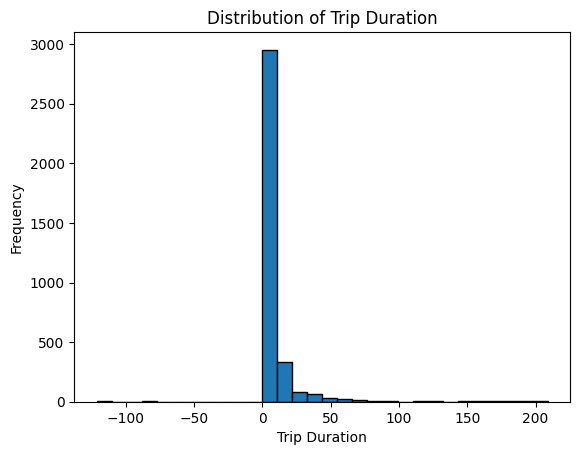

In [22]:
from matplotlib.pyplot import hist

hist(df['Trip Duration'], bins=30, edgecolor='black')
plt.title('Distribution of Trip Duration')
plt.xlabel('Trip Duration')
plt.ylabel('Frequency')

In [23]:
# Remove negative Trip Duration rows
print(f"Before remove non-validity value: {len(df)} rows")
df = df[df['Trip Duration'] >= 0]
print(f"After remove non-validity value: {len(df)} rows")

Before remove non-validity value: 3558 rows
After remove non-validity value: 3551 rows


Text(0.5, 0, 'Trip Duration (days)')

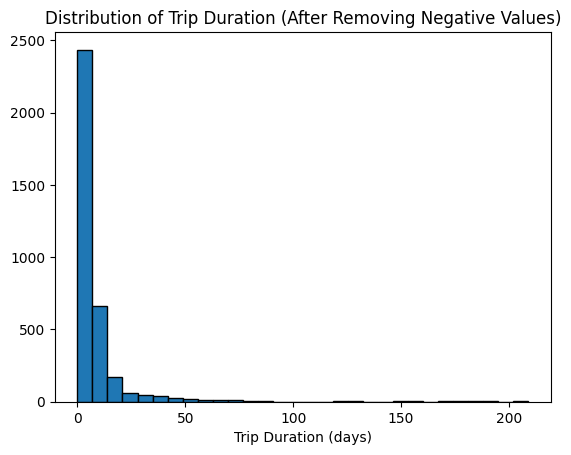

In [24]:
hist(df['Trip Duration'], bins=30, edgecolor='black')
plt.title('Distribution of Trip Duration (After Removing Negative Values)')
plt.xlabel('Trip Duration (days)')

In [25]:
df.head(5)

,Gps Provider,Booking ID,Shipment Type,Booking Date,Vehicle Registration,Origin Location,Destination Location,Origin Location Latitude,Origin Location Longitude,Destination Location Latitude,Destination Location Longitude,Data Ping time,Planned ETA,Current Location,Actual Time Arrival,Current Location Latitude,Current Location Longitude,Ontime,Trip Start Date,Estimate Time Arrival,Transportation Distance (KM),Vehicle Type,Driver Name,Customer Name,Supplier Name,Material Shipped,Trip Duration
0,Consent Track,AEIBK2027469,Regular,2020-08-26,MH14GD9464,"Shive, Pune, Maharashtra","Pondur, Kanchipuram, Tamil Nadu",18.750621,73.877190,12.930429,79.931163,0 days 15:10:00,0 days 03:46:00,"Singaperumal Koil - Sriperumbudur Rd, Oragadam...",2020-08-28 12:48:00,12.837127,79.951866,Yes,2020-08-26 16:16:00,2020-08-28 12:15:00,1290.0,32 FT Multi-Axle 14MT - HCV,VIRAT NILAPALLE,Daimler India Commercial Vehicles Pvt Lt,Oms Logistics Pvt Ltd,Regulator - 12v,1
1,Vamosys,VCV00014153/082021,Regular,2020-08-27,TN30BC9320,"Daimler India Commercial Vehicles,Kanchipuram,...","Daimler India Commercial Vehicles,Kanchipuram,...",12.839000,79.954000,12.839000,79.954000,1 days 11:40:00,0 days 21:48:36,"Gokulapuram Main Rd, Maraimalai Nagar, Tamil N...",2020-08-28 12:13:00,12.768090,80.026660,Yes,2020-08-27 15:21:00,2020-08-27 15:21:00,29.0,Not Specified,SENTHIL KUMAR,Daimler India Commercial Vehicles Pvt Lt,Vj Logistics,Valve Spring,0
2,Vamosys,VCV00014063/082021,Regular,2020-08-27,TN30BB1036,"Daimler India Commercial Vehicles,Kanchipuram,...","Daimler India Commercial Vehicles,Kanchipuram,...",12.839000,79.954000,12.839000,79.954000,1 days 01:38:00,0 days 22:17:48,"Singaperumal Koil - Sriperumbudur Rd, Oragadam...",2020-08-28 11:33:00,12.835262,79.952533,Yes,2020-08-27 14:21:00,2020-08-27 14:22:00,21.0,Not Specified,ANBU,Daimler India Commercial Vehicles Pvt Lt,Vj Logistics,Valve Spring,0
3,Vamosys,VCV00014741/082021,Regular,2020-08-28,TN88D4134,"Daimler India Commercial Vehicles,Kanchipuram,...","Daimler India Commercial Vehicles,Kanchipuram,...",12.839000,79.954000,12.839000,79.954000,1 days 01:37:00,1 days 08:20:30,"Unnamed Road, Oragadam Industrial Corridor, Or...",2020-08-28 11:31:00,12.839172,79.951355,Yes,2020-08-28 00:31:00,2020-08-28 00:32:00,20.0,Not Specified,SUDHAKAR,Daimler India Commercial Vehicles Pvt Lt,Namakkal Sri Anjinaya Transport,Lu Hood Lock / Rh,0
4,Consent Track,AEIBK2027446,Regular,2020-08-26,GJ01DZ8943,"Khorajnanoda, Ahmedabad, Gujarat","Singaperumalkoil, Kanchipuram, Tamil Nadu",22.961777,72.094219,12.786517,79.975221,1 days 11:08:00,2 days 07:08:00,"Rajmata Jijau Marg, Suhash Colony, Beed, Mahar...",2020-08-29 07:09:00,18.996400,75.740200,Yes,2020-08-26 15:35:00,2020-08-28 11:21:00,1900.0,32 FT Single-Axle 7MT - HCV,MAN SINGH,Ford India Private Limited,Sterling Translogistics Private Limited,Lu Latch / Pin,2


### Feature Engineering for Route Efficiency Analysis

In [26]:
# 1. Route Efficiency Metrics Distance per day of travel
df['Distance_per_Day'] = df['Transportation Distance (KM)'] / (df['Trip Duration'] + 1)

# 2. 
df['SLA_Target_Time'] = df['Trip Start Date'] + df['Planned ETA']

df['Delay Time (Days)'] = np.where(
    df['Actual Time Arrival'] > df['SLA_Target_Time'], 
    (df['Actual Time Arrival'] - df['SLA_Target_Time']).dt.total_seconds() / 86400,
    0
)

# 3. Day of Week Analysis
df['Booking_Day_of_Week'] = pd.to_datetime(df['Booking Date']).dt.day_name()
df['Trip_Start_Day_of_Week'] = df['Trip Start Date'].dt.day_name()
df['Actual_Arrival_Day_of_Week'] = df['Actual Time Arrival']
df['Is_Weekend'] = df['Trip Start Date'].dt.day_of_week.isin([5, 6]).astype(int)


# 4. Trip Duration Categories
df['Trip_Duration_Category'] = pd.cut(df['Trip Duration'], 
                                       bins=[0, 1, 3, 7, float('inf')], 
                                       labels=['Same Day', 'Short (2-3 days)', 'Medium (4-7 days)', 'Long (>7 days)'])

# 5. Distance Categories
df['Distance_Category'] = pd.cut(df['Transportation Distance (KM)'], 
                                  bins=[0, 250, 500, 1000, float('inf')], 
                                  labels=['Short (<250 km)', 'Medium (250-500 km)', 'Long (500-1000 km)', 'Very Long (>1000 km)'])

print("New features created:")
print(df[['Distance_per_Day', 'Delay Time (Days)', 'Is_Weekend', 'Trip_Duration_Category', 'Distance_Category']].head(10))

## 6. Movement type
def get_city(loc_str):
    if pd.isna(loc_str):
        return 'Unknown'
    parts = str(loc_str).split(',')
    if len(parts) >= 2:
        return parts[-2].strip()
    return str(loc_str).strip()

df['Origin City'] = df['Origin Location'].apply(get_city)
df['Destination City'] = df['Destination Location'].apply(get_city)

df['movement_type'] = np.where(
    df['Origin City'] == df['Destination City'],
    'Intra city',
    'Inter city'
)

print(df[['Origin City', 'Destination City', 'movement_type']])

## 7. Route
df['route_name'] = df['Origin Location'] + " - " + df['Destination Location']


New features created:
   Distance_per_Day  Delay Time (Days)  Is_Weekend Trip_Duration_Category  \
0        645.000000           1.698611           0               Same Day   
1         29.000000           0.000000           0                    NaN   
2         21.000000           0.000000           0                    NaN   
3         20.000000           0.000000           0                    NaN   
4        633.333333           0.351389           0       Short (2-3 days)   
5        200.000000           0.093056           0               Same Day   
6        242.000000           0.000000           0                    NaN   
7         21.000000           0.616111           0                    NaN   
8          3.000000           0.000000           0                    NaN   
9       1199.000000           0.000000           0                    NaN   

      Distance_Category  
0  Very Long (>1000 km)  
1       Short (<250 km)  
2       Short (<250 km)  
3       Short (<250 km)  


In [27]:
df.head(5)

,Gps Provider,Booking ID,Shipment Type,Booking Date,Vehicle Registration,Origin Location,Destination Location,Origin Location Latitude,Origin Location Longitude,Destination Location Latitude,Destination Location Longitude,Data Ping time,Planned ETA,Current Location,Actual Time Arrival,Current Location Latitude,Current Location Longitude,Ontime,Trip Start Date,Estimate Time Arrival,Transportation Distance (KM),Vehicle Type,Driver Name,Customer Name,Supplier Name,Material Shipped,Trip Duration,Distance_per_Day,SLA_Target_Time,Delay Time (Days),Booking_Day_of_Week,Trip_Start_Day_of_Week,Actual_Arrival_Day_of_Week,Is_Weekend,Trip_Duration_Category,Distance_Category,Origin City,Destination City,movement_type,route_name
0,Consent Track,AEIBK2027469,Regular,2020-08-26,MH14GD9464,"Shive, Pune, Maharashtra","Pondur, Kanchipuram, Tamil Nadu",18.750621,73.877190,12.930429,79.931163,0 days 15:10:00,0 days 03:46:00,"Singaperumal Koil - Sriperumbudur Rd, Oragadam...",2020-08-28 12:48:00,12.837127,79.951866,Yes,2020-08-26 16:16:00,2020-08-28 12:15:00,1290.0,32 FT Multi-Axle 14MT - HCV,VIRAT NILAPALLE,Daimler India Commercial Vehicles Pvt Lt,Oms Logistics Pvt Ltd,Regulator - 12v,1,645.000000,2020-08-26 20:02:00,1.698611,Wednesday,Wednesday,2020-08-28 12:48:00,0,Same Day,Very Long (>1000 km),Pune,Kanchipuram,Inter city,"Shive, Pune, Maharashtra - Pondur, Kanchipuram..."
1,Vamosys,VCV00014153/082021,Regular,2020-08-27,TN30BC9320,"Daimler India Commercial Vehicles,Kanchipuram,...","Daimler India Commercial Vehicles,Kanchipuram,...",12.839000,79.954000,12.839000,79.954000,1 days 11:40:00,0 days 21:48:36,"Gokulapuram Main Rd, Maraimalai Nagar, Tamil N...",2020-08-28 12:13:00,12.768090,80.026660,Yes,2020-08-27 15:21:00,2020-08-27 15:21:00,29.0,Not Specified,SENTHIL KUMAR,Daimler India Commercial Vehicles Pvt Lt,Vj Logistics,Valve Spring,0,29.000000,2020-08-28 13:09:36,0.000000,Thursday,Thursday,2020-08-28 12:13:00,0,NaN,Short (<250 km),Kanchipuram,Kanchipuram,Intra city,"Daimler India Commercial Vehicles,Kanchipuram,..."
2,Vamosys,VCV00014063/082021,Regular,2020-08-27,TN30BB1036,"Daimler India Commercial Vehicles,Kanchipuram,...","Daimler India Commercial Vehicles,Kanchipuram,...",12.839000,79.954000,12.839000,79.954000,1 days 01:38:00,0 days 22:17:48,"Singaperumal Koil - Sriperumbudur Rd, Oragadam...",2020-08-28 11:33:00,12.835262,79.952533,Yes,2020-08-27 14:21:00,2020-08-27 14:22:00,21.0,Not Specified,ANBU,Daimler India Commercial Vehicles Pvt Lt,Vj Logistics,Valve Spring,0,21.000000,2020-08-28 12:38:48,0.000000,Thursday,Thursday,2020-08-28 11:33:00,0,NaN,Short (<250 km),Kanchipuram,Kanchipuram,Intra city,"Daimler India Commercial Vehicles,Kanchipuram,..."
3,Vamosys,VCV00014741/082021,Regular,2020-08-28,TN88D4134,"Daimler India Commercial Vehicles,Kanchipuram,...","Daimler India Commercial Vehicles,Kanchipuram,...",12.839000,79.954000,12.839000,79.954000,1 days 01:37:00,1 days 08:20:30,"Unnamed Road, Oragadam Industrial Corridor, Or...",2020-08-28 11:31:00,12.839172,79.951355,Yes,2020-08-28 00:31:00,2020-08-28 00:32:00,20.0,Not Specified,SUDHAKAR,Daimler India Commercial Vehicles Pvt Lt,Namakkal Sri Anjinaya Transport,Lu Hood Lock / Rh,0,20.000000,2020-08-29 08:51:30,0.000000,Friday,Friday,2020-08-28 11:31:00,0,NaN,Short (<250 km),Kanchipuram,Kanchipuram,Intra city,"Daimler India Commercial Vehicles,Kanchipuram,..."
4,Consent Track,AEIBK2027446,Regular,2020-08-26,GJ01DZ8943,"Khorajnanoda, Ahmedabad, Gujarat","Singaperumalkoil, Kanchipuram, Tamil Nadu",22.961777,72.094219,12.786517,79.975221,1 days 11:08:00,2 days 07:08:00,"Rajmata Jijau Marg, Suhash Colony, Beed, Mahar...",2020-08-29 07:09:00,18.996400,75.740200,Yes,2020-08-26 15:35:00,2020-08-28 11:21:00,1900.0,32 FT Single-Axle 7MT - HCV,MAN SINGH,Ford India Private Limited,Sterling Translogistics Private Limited,Lu Latch / Pin,2,633.333333,2020-08-28 22:43:00,0.351389,Wednesday,Wednesday,2020-08-29 07:09:00,0,Short (2-3 days),Very Long (>1000 km),Ahmedabad,Kanchipuram,Inter city,"Khorajnanoda,

### Standardize Column Name

In [28]:
print("--- Before Rename ---")
print(df.columns.tolist()[:5])

df.columns = (
    df.columns
    .str.strip()                              
    .str.lower()                              
    .str.replace(r'[^\w\s]', '', regex=True)  
    .str.replace(r'\s+', '_', regex=True)     
)

print("\n--- After Rename ---")
print(df.columns.tolist()[:5])

--- Before Rename ---
['Gps Provider', 'Booking ID', 'Shipment Type', 'Booking Date', 'Vehicle Registration']

--- After Rename ---
['gps_provider', 'booking_id', 'shipment_type', 'booking_date', 'vehicle_registration']


### Data Quality Check

In [29]:
# Condition 1: ontime = Yes but delay_time_days > 0
cond1 = (df['ontime'].isin(['Yes'])) & (df['delay_time_days'] > 0)
count1 = cond1.sum()

# Condition 2: ontime = No (or not Yes) but delay_time_days <= 0
cond2 = (~df['ontime'].isin(['Yes'])) & (df['delay_time_days'] <= 0)
count2 = cond2.sum()

print(f"Số record có Ontime = 'Yes' nhưng Delay > 0 ngày: {count1}")
print(f"Số record có Ontime = 'No' nhưng Delay <= 0 ngày: {count2}")

# If there are any, let's show a couple of examples
if count1 > 0:
    print("\nVí dụ Ontime='Yes' mà Delay>0:")
    print(df[cond1][['booking_id', 'ontime', 'delay_time_days', 'sla_target_time', 'actual_time_arrival']].head(2))

if count2 > 0:
    print("\nVí dụ Ontime='No' mà Delay<=0:")
    print(df[cond2][['booking_id', 'ontime', 'delay_time_days', 'sla_target_time', 'actual_time_arrival']].head(2))

Số record có Ontime = 'Yes' nhưng Delay > 0 ngày: 637
Số record có Ontime = 'No' nhưng Delay <= 0 ngày: 90

Ví dụ Ontime='Yes' mà Delay>0:
     booking_id ontime  delay_time_days     sla_target_time  \
0  AEIBK2027469    Yes         1.698611 2020-08-26 20:02:00   
4  AEIBK2027446    Yes         0.351389 2020-08-28 22:43:00   

  actual_time_arrival  
0 2020-08-28 12:48:00  
4 2020-08-29 07:09:00  

Ví dụ Ontime='No' mà Delay<=0:
       booking_id ontime  delay_time_days     sla_target_time  \
189  AEIBK2026862     No              0.0 2020-08-26 18:47:00   
224  AEIBK2026920     No              0.0 2020-08-27 14:39:00   

    actual_time_arrival  
189 2020-08-26 14:46:00  
224 2020-08-26 23:35:00  


In [30]:
df['ontime_original'] = df['ontime']

# Apply the new rule: If delay <= 0 then 'Yes', else 'No'
df['ontime'] = df['delay_time_days'].apply(lambda x: 'Yes' if x <= 0 else 'No')

changed_records = (df['ontime_original'] != df['ontime']).sum()

print(f"Đã cập nhật lại nhãn 'ontime' cho {changed_records} records bị mâu thuẫn.")

# Check the new distribution
print("\nPhân bổ On-time sau khi chuẩn hóa:")
print(df['ontime'].value_counts())

df.drop(columns=['ontime_original'], inplace=True)

cond1 = (df['ontime'].isin(['Yes'])) & (df['delay_time_days'] > 0)
count1 = cond1.sum()

# Condition 2: ontime = No (or not Yes) but delay_time_days <= 0
cond2 = (~df['ontime'].isin(['Yes'])) & (df['delay_time_days'] <= 0)
count2 = cond2.sum()

print(f"Số record có Ontime = 'Yes' nhưng Delay > 0 ngày: {count1}")
print(f"Số record có Ontime = 'No' nhưng Delay <= 0 ngày: {count2}")

Đã cập nhật lại nhãn 'ontime' cho 727 records bị mâu thuẫn.

Phân bổ On-time sau khi chuẩn hóa:
ontime
No     2734
Yes     817
Name: count, dtype: int64
Số record có Ontime = 'Yes' nhưng Delay > 0 ngày: 0
Số record có Ontime = 'No' nhưng Delay <= 0 ngày: 0


In [31]:
zero_dist_df = df[df['transportation_distance_km'] == 0].copy()

total_zero = len(zero_dist_df)

if total_zero > 0:
    zero_dist_df['is_same_loc'] = zero_dist_df['origin_location'].str.lower() == zero_dist_df['destination_location'].str.lower()
    print("Have same origin and destination location")
    print(zero_dist_df['is_same_loc'].value_counts())
    print("-" * 30)

    cols_to_show = ['booking_id', 'supplier_name', 'origin_location', 'destination_location', 'trip_start_date', 'trip_duration', 'ontime']
    
    print("Example:")
    print(zero_dist_df[cols_to_show].sample(min(5, total_zero)))

df = df[df['transportation_distance_km'] > 0].copy()

Have same origin and destination location
is_same_loc
True    25
Name: count, dtype: int64
------------------------------
Example:
        booking_id          supplier_name                     origin_location  \
1602  AEIBK2021578  Sree Sakthi Transport  Onnalvadi, krishnagiri, tamil nadu   
1610  AEIBK2024581  Sree Sakthi Transport  Onnalvadi, krishnagiri, tamil nadu   
1603  AEIBK2022963  Sree Sakthi Transport  Onnalvadi, krishnagiri, tamil nadu   
1608  AEIBK2021307  Sree Sakthi Transport  Onnalvadi, krishnagiri, tamil nadu   
2437  AEIBK2021182  Sree Sakthi Transport  Onnalvadi, krishnagiri, tamil nadu   

                    destination_location     trip_start_date  trip_duration  \
1602  Onnalvadi, Krishnagiri, Tamil Nadu 2020-06-29 09:42:00             36   
1610  Onnalvadi, Krishnagiri, Tamil Nadu 2020-08-01 08:53:00              3   
1603  Onnalvadi, Krishnagiri, Tamil Nadu 2020-07-17 08:40:00             18   
1608  Onnalvadi, Krishnagiri, Tamil Nadu 2020-06-25 12:24:00      

In [32]:
df['transportation_distance_km'].describe()

count    3526.000000
mean      852.862110
std       847.528054
min         3.000000
25%       110.000000
50%       451.000000
75%      1300.000000
max      2898.000000
Name: transportation_distance_km, dtype: float64

## Load

In [33]:
from dotenv import load_dotenv
from sqlalchemy import create_engine
import time

load_dotenv('key.env')

db_user = os.getenv('DB_USER')
db_password = os.getenv('DB_PASSWORD')
db_host = os.getenv('DB_HOST')
db_port = os.getenv('DB_PORT')
db_name = os.getenv('DB_NAME')

if not all([db_user, db_password, db_host, db_port, db_name]):
    raise ValueError("Missing database credentials in key.env file.")

engine = create_engine(f'postgresql://{db_user}:{db_password}@{db_host}:{db_port}/{db_name}')

print("Start loading data into PostgreSQL...")

table_name = 'logistics_tracking_data' 
start_time = time.time()

df.to_sql(
    name=table_name, 
    con=engine, 
    if_exists='replace',
    index=False, 
    chunksize=50000,  
    method='multi'    
)

end_time = time.time()
print(f"Done in {round(end_time - start_time, 2)} giây!")

Start loading data into PostgreSQL...


C:\Users\AD\AppData\Local\Temp\ipykernel_20660\1636834436.py:23: UserWarning: the 'timedelta' type is not supported, and will be written as integer values (ns frequency) to the database.
  df.to_sql(


Done in 29.46 giây!


In [ ]:
df.to_parquet("../data/Cleaned_Transportation_Data.parquet", index=False)